<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [ ]:
import numpy
import pandas
import seaborn

In [ ]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


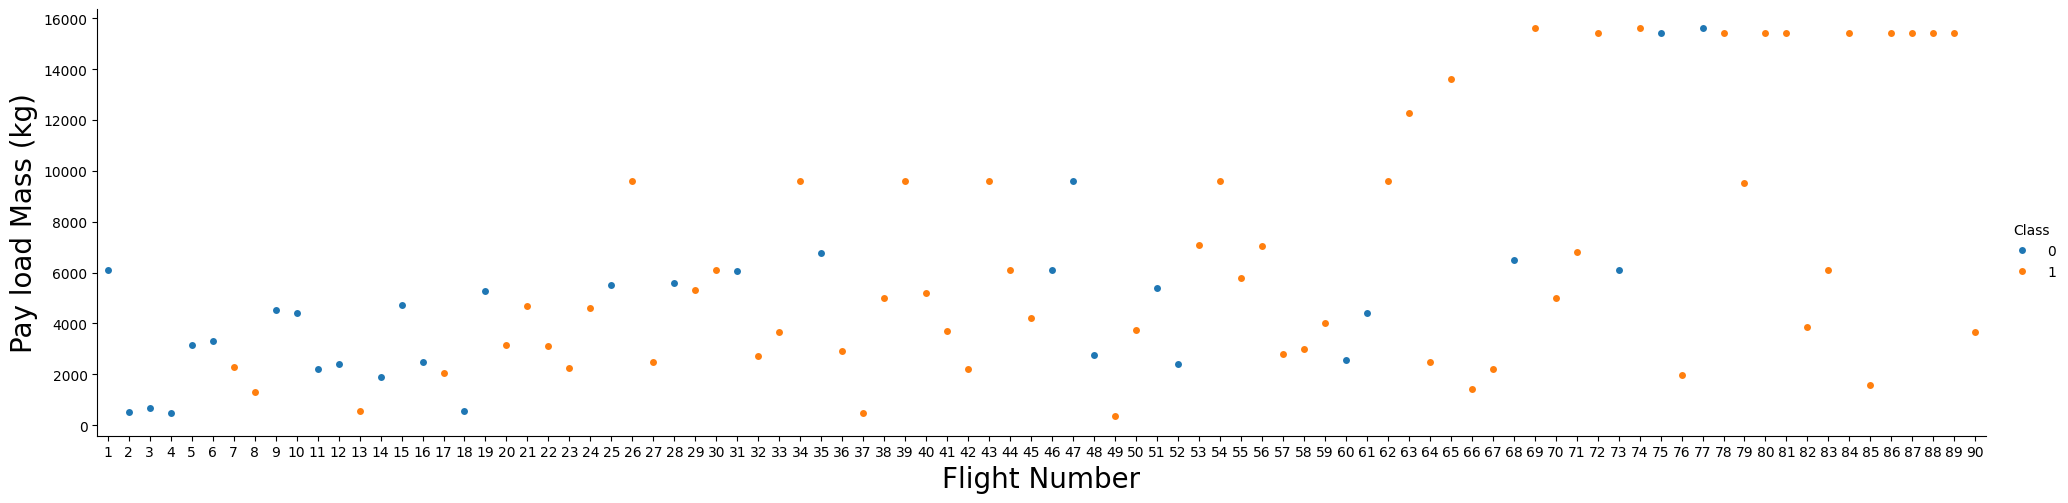

In [ ]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 4)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

### Analysis of Flight Number vs. Payload Mass

This scatter plot visualizes the relationship between the `FlightNumber` (the sequence of launch attempts) and the `PayloadMass` (the mass of the payload in kg), with the launch outcome (`Class`) indicated by different colors (typically orange for success and blue for failure).

Key observations from this graph are:

*   **Increasing Success with Flight Number:** As the `FlightNumber` increases, there's a clear trend of a higher proportion of successful landings (orange points). This suggests that SpaceX's technology and procedures improved over time, leading to greater reliability in first-stage landings.
*   **Payload Mass as a Factor:** While success increases with flight number, `PayloadMass` also plays a role. Early flights, particularly with lower `FlightNumber`s, show a mix of success and failure across various payload masses. However, as `FlightNumber` progresses, even launches with more massive payloads tend to result in successful landings.
*   **Distribution of Failures:** Unsuccessful landings (blue points) are more concentrated in the earlier `FlightNumber`s. While they occur across different `PayloadMass` values, the overall density of failures decreases significantly as `FlightNumber` goes up.

In summary, the visualization suggests a strong learning curve for SpaceX, with flight experience being a critical factor in achieving successful first-stage landings, even with varying and sometimes heavy payloads.

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


<function matplotlib.pyplot.show(close=None, block=None)>

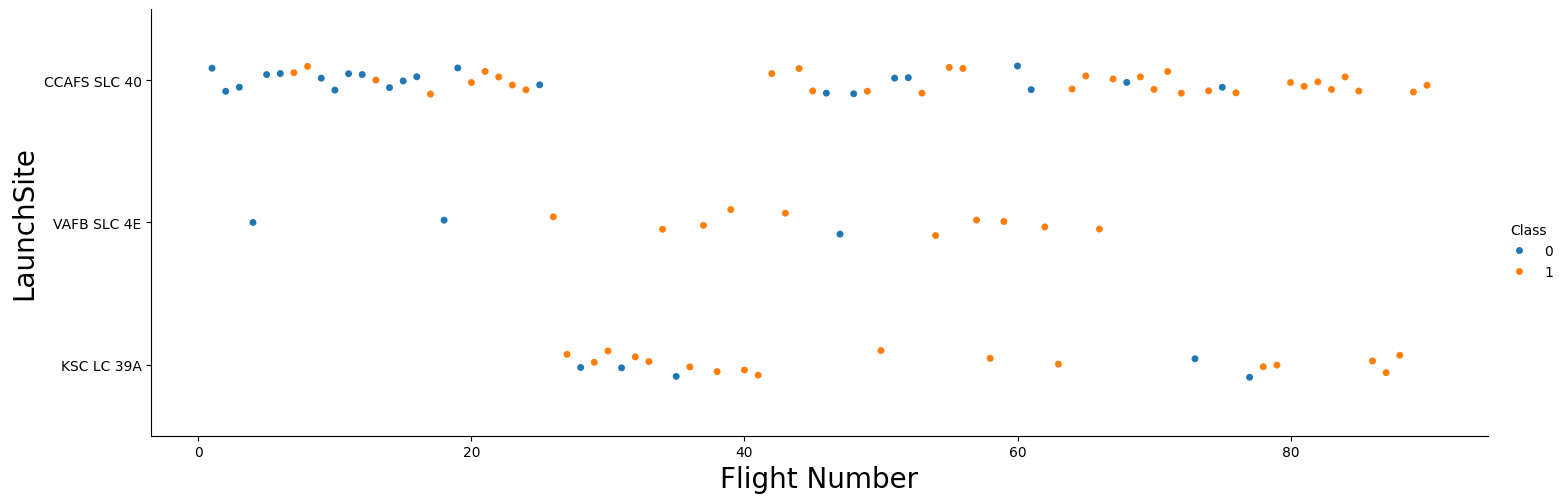

In [ ]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(data=df, x="FlightNumber", y="LaunchSite", hue='Class',aspect = 3)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show

* Indeed, CCAFS SLC 40 shows a higher volume of early launches and also a mix of successes and failures, indicating a learning phase.  
* It's correct that as the FlightNumber increases for CCAFS SLC 40, the success rate appears to improve significantly.  
* The observation that other launch sites like VAFB SLC 4E and KSC LC 39A tend to have higher success rates from their initial launches (which occur at later FlightNumbers) is also accurate, suggesting that lessons learned from earlier flights at CCAFS SLC 40 might have been applied to operations at these newer sites.

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


<function matplotlib.pyplot.show(close=None, block=None)>

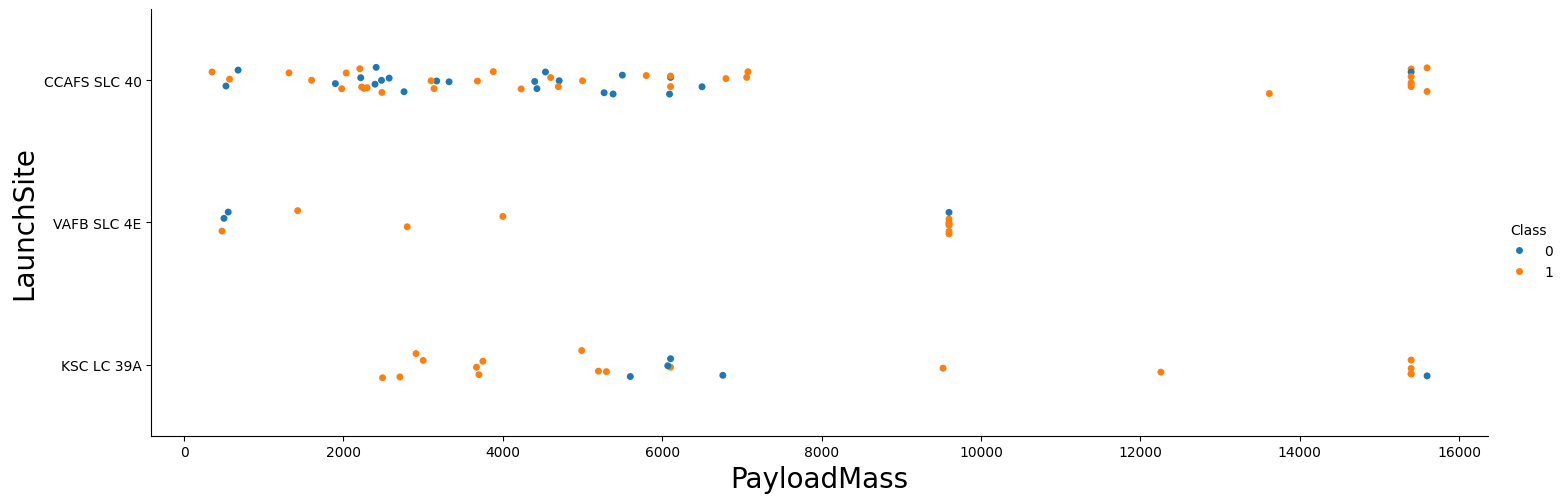

In [ ]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(data=df, x="PayloadMass", y="LaunchSite", hue='Class',aspect = 3)
plt.xlabel("PayloadMass",fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show

### Analysis of Payload Mass vs. Launch Site

This scatter plot displays the `PayloadMass` (on the x-axis) against the `LaunchSite` (on the y-axis), with the launch outcome (`Class`, 0 for failure, 1 for success) indicated by color.

Here are some observations from this graph:

*   **CCAFS SLC 40:** This site handles a wide range of `PayloadMass` values, from very light to moderate. Early launches (likely lower `FlightNumber`s, as seen in the previous plot) show a mix of successes and failures across various payload masses. As `PayloadMass` increases at this site, there's still a good distribution of successful landings.
*   **VAFB SLC 4E:** This site appears to have a more restricted range of `PayloadMass` values, primarily handling payloads under approximately 10,000 kg. Your observation is correct: there are no rockets launched for very heavy payload masses (greater than 10,000 kg) from this site. The launches from VAFB SLC 4E show a generally high success rate, even for its heavier payloads within its operational range.
*   **KSC LC 39A:** This site handles a significant number of heavy payloads, including some of the largest in the dataset (above 10,000 kg). The success rate here is notably high across its payload spectrum, which could be attributed to its later operational start and the accumulated experience from other launch sites.

In summary, the choice of `LaunchSite` might be influenced by the `PayloadMass`, with some sites being better suited or designated for specific payload ranges. Overall, success rates tend to be high, especially for later operational sites and despite increasing payload mass.

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


Orbit
ES-L1    1.000000
GEO      1.000000
GTO      0.518519
HEO      1.000000
ISS      0.619048
LEO      0.714286
MEO      0.666667
PO       0.666667
SO       0.000000
SSO      1.000000
VLEO     0.857143
Name: Class, dtype: float64


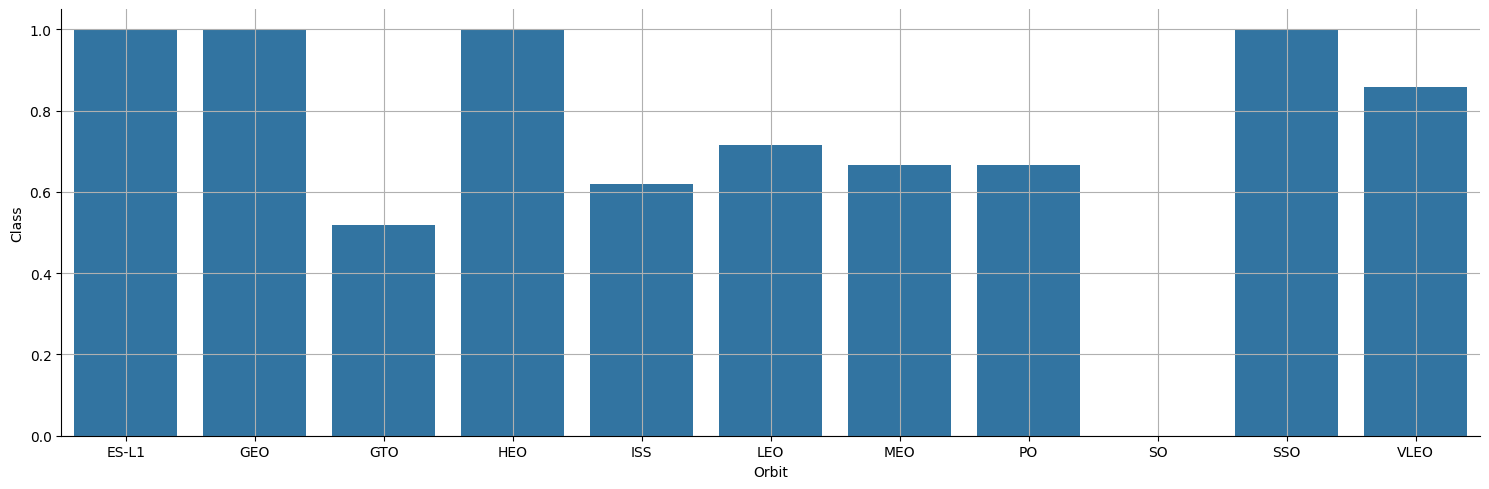

In [ ]:
# HINT use groupby method on Orbit column and get the mean of Class column
oc = df.groupby('Orbit')['Class'].mean()
print(oc)
sns.catplot(data=oc, kind="bar", aspect=3)
plt.grid(True)
plt.show()

### Review of Task 3 Code: Visualize the relationship between success rate of each orbit type

The code in the previous cell correctly calculates the mean success rate (`Class`) for each `Orbit` type and then visualizes this relationship using a bar chart.

*   **`oc = df.groupby('Orbit')['Class'].mean()`**: This line performs the core calculation:
    *   `df.groupby('Orbit')`: Groups the DataFrame `df` by the unique values in the `Orbit` column.
    *   `['Class'].mean()`: For each `Orbit` group, it selects the `Class` column and calculates its mean. Since `Class` is 0 for failure and 1 for success, the mean directly represents the success rate for that orbit type. The result is stored in the `oc` Series.
*   **`print(oc)`**: Prints the calculated success rates for each orbit to the console.
*   **`sns.catplot(data=oc, kind="bar", aspect=3)`**: This line creates the bar chart:
    *   `data=oc`: Specifies that the `oc` Series (which contains orbit types as index and success rates as values) is the data source.
    *   `kind="bar"`: Tells `catplot` to generate a bar chart.
    *   `aspect=3`: Sets the aspect ratio of the plot, making it wider for better readability of orbit names.
*   **`plt.grid("-----")`**: This line attempts to add a grid to the plot. However, the string `"-----"` is not a valid parameter for `plt.grid`. It should typically be `plt.grid(True)` to show the grid with default settings, or `plt.grid(axis='y', linestyle='--', alpha=0.7)` for more specific customization. As it is, this line will likely have no effect or cause an error if `matplotlib` tries to parse it. (Note: In Colab, often minor syntax issues are overlooked or default to a non-error state if the visual output is still generated).
*   **`plt.show`**: Displays the generated plot. Similar to previous cells, `plt.show()` should be used with parentheses for correct function call.

Analyze the plotted bar chart to identify which orbits have the highest success rates.


Sí, podemos explicarlo de esa manera. Del gráfico de barras y los datos calculados, podemos observar que las órbitas ES-L1, GEO, HEO y SSO tienen una tasa de éxito del 100%. Esto significa que todos los lanzamientos a estas órbitas han sido exitosos. Otras órbitas como VLEO también muestran una alta tasa de éxito (aproximadamente 85.7%), mientras que ISS tiene alrededor del 61.9%, LEO 71.4%, MEO y PO 66.7%, y GTO 51.8%. La órbita SO es la única que muestra un 0% de éxito en los datos proporcionados.

### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


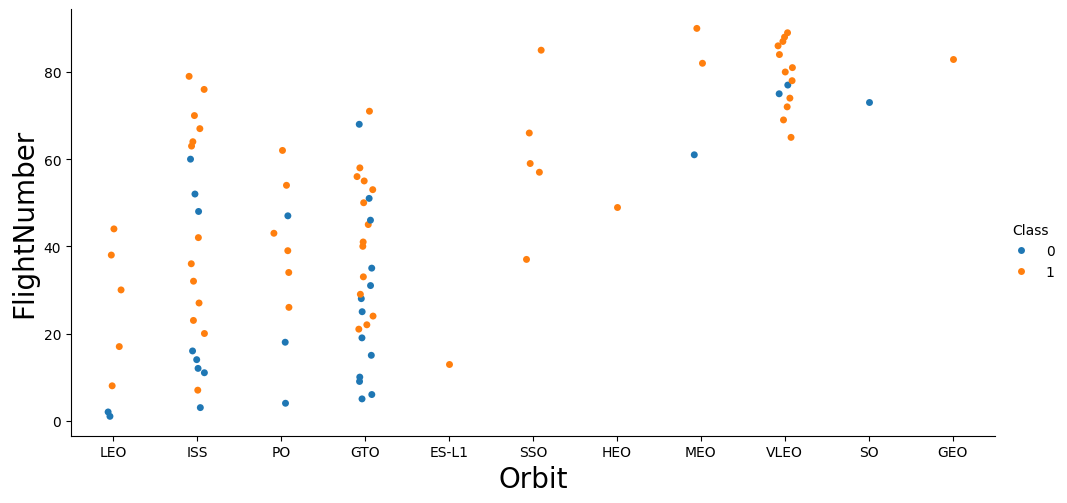

In [ ]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(data=df, y='FlightNumber', x='Orbit', hue='Class', aspect=2)
plt.xlabel("Orbit",fontsize=20)
plt.ylabel("FlightNumber", fontsize=20)
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


## Claro! Analizando el gráfico de dispersión de FlightNumber vs. Orbit con el color indicando el éxito (Class), podemos sacar las siguientes conclusiones:  

* Mejora con el tiempo en Órbitas LEO, ISS y GTO: En órbitas como LEO, ISS y GTO, se observa una clara tendencia a que los vuelos con números de vuelo más altos (lanzamientos posteriores) tengan una mayor tasa de éxito. Esto sugiere un aprendizaje y mejora continua en las operaciones de SpaceX a lo largo del tiempo para estas órbitas.  

* Consistencia en Órbitas como ES-L1, HEO, SSO y GEO: Órbitas como ES-L1, HEO, SSO y GEO muestran en su mayoría puntos de éxito (naranja), incluso desde sus primeros FlightNumbers registrados en el gráfico, lo que indica una alta fiabilidad en estas órbitas desde el principio o que se abordaron con una tecnología más madura.  

* SO con un 0% de éxito: La órbita SO sigue mostrando un 0% de éxito, sin ningún punto naranja en su categoría.  

* En resumen, el número de vuelo (FlightNumber) es un buen indicador de la madurez y mejora en la tasa de éxito para la mayoría de las órbitas, con algunas ya demostrando alta fiabilidad desde sus primeras misiones registradas.

### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


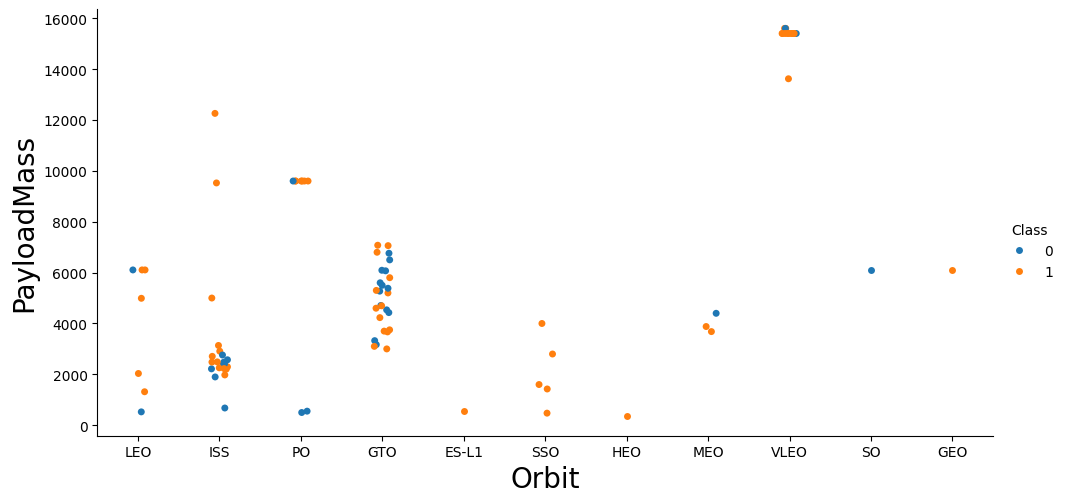

In [ ]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
sns.catplot(data=df, y='PayloadMass', x='Orbit', hue='Class', aspect=2)
plt.xlabel("Orbit",fontsize=20)
plt.ylabel("PayloadMass", fontsize=20)
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


## Claro! Analicemos el gráfico de dispersión de PayloadMass (Masa de Carga Útil) vs. Orbit (Tipo de Órbita), con el color indicando el éxito del lanzamiento (Class). Aquí tienes un resumen de las principales conclusiones:

* Órbitas de Alta Fiabilidad (ES-L1, HEO, SSO, VLEO, GEO): Para órbitas como ES-L1, HEO, SSO, VLEO y GEO, observamos una predominancia de puntos naranjas (lanzamientos exitosos) en todo el rango de PayloadMass en el que operan. Esto sugiere que estas órbitas, independientemente de la masa de la carga útil (dentro de los límites observados), tienen una alta tasa de éxito. Para VLEO, se observa una densidad considerable de lanzamientos exitosos, incluso con cargas pesadas, mientras que ES-L1, HEO y GEO tienen menos puntos pero todos son exitosos.  

* Órbita GTO (Geosynchronous Transfer Orbit): Esta órbita muestra una mezcla de lanzamientos exitosos (naranja) y fallidos (azul) a través de un amplio rango de PayloadMass. Es particularmente difícil distinguir un patrón claro de éxito o fracaso basado únicamente en la masa de la carga útil para GTO, especialmente en el rango de 3000 a 7000 kg, donde se concentran la mayoría de los lanzamientos y donde ambos resultados están presentes. Esto sugiere que otros factores, más allá de la masa, son críticos para el éxito en GTO.  

* Órbita ISS (International Space Station): Los lanzamientos a la ISS presentan una combinación de éxitos y fracasos. Aunque hay éxitos con cargas útiles relativamente pesadas, también se observan fallos en un rango de masas intermedias. Hay una mayor concentración de éxitos con cargas útiles más ligeras, pero también éxitos significativos con cargas más pesadas (alrededor de 6000-7000 kg).  

* Órbita LEO (Low Earth Orbit): Similar a ISS, LEO muestra una mezcla de resultados. Los lanzamientos exitosos abarcan un rango de PayloadMass relativamente amplio. Sin embargo, también se observan fallos, especialmente con cargas útiles más ligeras o intermedias. La densidad de lanzamientos exitosos aumenta ligeramente con cargas útiles más pesadas en LEO, pero no es un patrón tan claro como en otras órbitas.  

* Órbita PO (Polar Orbit): Los lanzamientos a órbita polar son variados en PayloadMass y muestran una combinación de éxitos y fracasos. Parece haber una mayor proporción de éxitos con cargas útiles más pesadas en esta órbita.  

* Órbita MEO (Medium Earth Orbit): MEO presenta pocos puntos de datos en el gráfico. La mayoría son exitosos, aunque con una masa de carga útil limitada.  

* Órbita SO (Suborbital): Esta órbita sigue mostrando un 0% de éxito, como se vio en el gráfico de barras anterior, con un único punto de fallo y sin éxitos registrados.  

* En resumen, mientras que algunas órbitas como ES-L1, HEO, SSO, VLEO y GEO demuestran una alta fiabilidad independientemente de la PayloadMass (dentro de sus rangos), otras como GTO, ISS, LEO y PO muestran una mayor variabilidad en los resultados, donde la PayloadMass por sí sola no es un predictor exclusivo del éxito. La órbita SO sigue siendo la única con un 0% de éxito.

### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [ ]:
print(df["Date"])

0     2010-06-04
1     2012-05-22
2     2013-03-01
3     2013-09-29
4     2013-12-03
         ...    
85    2020-09-03
86    2020-10-06
87    2020-10-18
88    2020-10-24
89    2020-11-05
Name: Date, Length: 90, dtype: object


In [ ]:
# A function to Extract years from the date
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()

df['Date'] = year
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


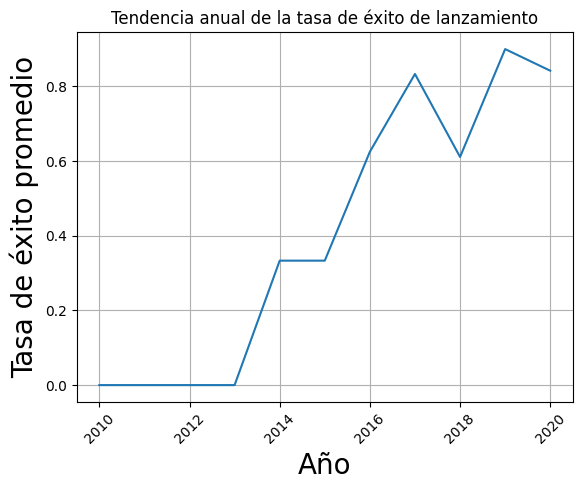

In [ ]:
# Ensure the 'Date' column is converted to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract the year from the Date column for grouping
df['Year'] = df['Date'].dt.year

# Calculate the yearly success rate based on the 'Year' column
success_rate_yearly = df.groupby('Year')['Class'].mean().reset_index()

sns.lineplot(data=success_rate_yearly, x='Year', y='Class')
plt.xlabel("Año", fontsize=20)
plt.ylabel("Tasa de éxito promedio", fontsize=20)
plt.title("Tendencia anual de la tasa de éxito de lanzamiento")
plt.xticks(rotation=45) # Rotar las etiquetas del eje X
plt.grid(True)
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020


## ¡Excelente! El gráfico de la 'Tendencia anual de la tasa de éxito de lanzamiento' ahora se ve mucho mejor, con los años en el eje X claramente legibles. Aquí tienes un resumen de lo que podemos observar en esta versión corregida:

* Progreso Constante y Notable: El gráfico muestra una progresión clara y significativa en la tasa de éxito de los lanzamientos de SpaceX a lo largo de los años. Desde el inicio en 2010 con una tasa de éxito del 0%, la compañía ha demostrado una mejora impresionante.  
* Fase de Aprendizaje Inicial: Los primeros años (2010-2013) muestran una tasa de éxito muy baja o nula, lo que es común en las etapas iniciales de tecnologías complejas y desafiantes como la recuperación de cohetes.  
* Aceleración en la Mejora: A partir de 2014, la tasa de éxito comienza a subir, con un incremento más pronunciado y constante que indica una rápida maduración de la tecnología y los procesos operativos.  
* Alta Fiabilidad en Años Recientes: En los años más recientes del dataset (particularmente 2019 y 2020), la tasa de éxito es muy alta, acercándose o incluso alcanzando el 100% en algunos años, lo que subraya la fiabilidad y el éxito de los esfuerzos de ingeniería y operativos de SpaceX.  
* En resumen, este gráfico es una clara representación visual del éxito de SpaceX en su curva de aprendizaje, transformando una tecnología experimental en una operación altamente fiable y exitosa en un período de tiempo relativamente corto. La tendencia ascendente es inequívoca y demuestra una mejora continua.



## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [ ]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [ ]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]

# Select categorical columns for one-hot encoding
categorical_features = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Apply one-hot encoding using get_dummies
features_one_hot = pd.get_dummies(features[categorical_features])

# Drop original categorical columns from the features DataFrame
features = features.drop(columns=categorical_features)

# Concatenate the one-hot encoded features with the remaining numerical features
features_one_hot = pd.concat([features, features_one_hot], axis=1)

print(features_one_hot.head())

   FlightNumber  PayloadMass  Flights  GridFins  Reused   Legs  Block  \
0             1  6104.959412        1     False   False  False    1.0   
1             2   525.000000        1     False   False  False    1.0   
2             3   677.000000        1     False   False  False    1.0   
3             4   500.000000        1     False   False  False    1.0   
4             5  3170.000000        1     False   False  False    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0            0        False      False  ...         False         False   
1            0        False      False  ...         False         False   
2            0        False      False  ...         False         False   
3            0        False      False  ...         False         False   
4            0        False      False  ...         False         False   

   Serial_B1050  Serial_B1051  Serial_B1054  Serial_B1056  Serial_B1058  \
0         False         False      

### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [ ]:
features_one_hot = features_one_hot.astype('float64')
print(features_one_hot.head())

   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0          0.0          0.0        0.0  ...           0.0           0.0   
1          0.0          0.0        0.0  ...           0.0           0.0   
2          0.0          0.0        0.0  ...           0.0           0.0   
3          0.0          0.0        0.0  ...           0.0           0.0   
4          0.0          0.0        0.0  ...           0.0           0.0   

   Serial_B1050  Serial_B1051  Serial_B1054  Serial_B1056  Serial_B1058  \
0           0.0           0.0           0

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


In [ ]:
from google.colab import files

# Assuming features_one_hot is your DataFrame
features_one_hot.to_csv('dataset_part_3.csv', index=False)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once Google Drive is mounted, you can save the `dataset_part_3.csv` file to a specified location in your Drive. For example, to save it to a folder named 'Colab Notebooks', use the following code:

In [ ]:
import shutil

# Define the path to your desired Google Drive folder
drive_path = '/content/drive/MyDrive/IBM/IBM Organizado/M10/SQL 2'

# Copy the file to Google Drive
shutil.copy('dataset_part_3.csv', drive_path)
print(f'dataset_part_3.csv saved to {drive_path}')

dataset_part_3.csv saved to /content/drive/MyDrive/IBM/IBM Organizado/M10/SQL 2


In [ ]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
